In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from lime import lime_tabular
import plotly.express as px
import random
import shap
import warnings
warnings.filterwarnings('ignore')


In [5]:
pip install shap

  Using cached shap-0.46.0-cp312-cp312-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.46.0-cp312-cp312-win_amd64.whl (456 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
def generate_dataset():
    # Load and prepare the data
    id_1 = 8175 #change to first student id
    id_2 = 0000 #change to second student id
    id_3 = 0000 #change to third student id "leave 0000 if team of 2"
    random_seed = id_1+id_2+id_3
    random.seed(random_seed)
    data_path="data.csv"
    output_path="your_data.csv"#replace with output data path

    all_data=pd.read_csv(data_path) 
    all_columns = all_data.columns.tolist()

    target_column = 'smoking'  

    all_columns.remove(target_column)
    all_columns.remove('id')

    selected_columns = random.sample(all_columns, 10)

    print(selected_columns) #MUST BE PRINTED
    selected_columns = np.append(selected_columns, target_column)
    sample_df = all_data[selected_columns].copy()
    sample_df.to_csv(output_path)
    return sample_df#From HERE YOU CAN SPLIT FOR TRAIN ,VALID AND TEST

In [8]:
def split_data(df, target_col='smoking'):
    #splitting to data to validation and training
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    print("Data split sizes:")
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [9]:
def perform_univariate_analysis(df):

    #Perform univariate analysis on each feature
    
    for column in df.columns:
        plt.figure(figsize=(10, 6))
        
        # For numerical columns
        if df[column].dtype in ['int64', 'float64']:
            # Distribution plot
            sns.histplot(data=df, x=column, kde=True)
            plt.title(f'Distribution of {column}')
            
            # Box plot
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df, x=column)
            plt.ylabel(column)
            plt.title(f'Box Plot of {column}')
            
        # For categorical columns
        else:
            sns.countplot(data=df, x=column)
            plt.title(f'Count Plot of {column}')
            
        plt.xticks(rotation=45)
        plt.show()
        
        # Print basic statistics
        print(f"\nSummary Statistics for {column}:")
        print(df[column].describe())
        print("\n" + "="*50 + "\n")

In [10]:
def perform_bivariate_analysis(df, target):
   
    for column in df.columns:
        if column != target:
            plt.figure(figsize=(10, 6))
            
            # For numerical columns
            if df[column].dtype in ['int64', 'float64']:
                sns.boxplot(data=df, x=target, y=column)
                plt.title(f'Box Plot of {column} by {target}')
                
            # For categorical columns
            else:
                sns.heatmap(pd.crosstab(df[column], df[target], normalize='index'),
                           annot=True, cmap='YlGnBu')
                plt.title(f'Heatmap of {column} vs {target}')
                
            plt.xticks(rotation=45)
            plt.show()

In [11]:
def perform_multivariate_analysis(df):
    # Correlation matrix
    plt.figure(figsize=(12, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.show()
    
    # Pair plot for numerical columns to assess interactions
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numerical_cols) > 1:
        sns.pairplot(df[numerical_cols], diag_kind='kde', hue='smoking')  # Use target variable for hue
        plt.title('Pair Plot of Numerical Features')
        plt.show()
    
    # Dimensionality Reduction using PCA
    from sklearn.decomposition import PCA
    
    # Standardizing the data
    from sklearn.preprocessing import StandardScaler
    X = df[numerical_cols].drop(columns='smoking')  # Exclude target variable
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    
    # Create a DataFrame for the PCA results
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    pca_df['smoking'] = df['smoking'].values  # Add target variable for coloring
    
    # Plot PCA results
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='smoking', alpha=0.7)
    plt.title('PCA of Numerical Features')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Smoking Status')
    plt.show()

In [3]:
def perform_feature_engineering(X_train, X_val, X_test,y_train):
    # Initialize scalers
    scaler = StandardScaler()
    
    # Scale the features
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Handle outliers using IQR method
    def remove_outliers(X):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        outlier_mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
        return X[outlier_mask], outlier_mask
    categorical_cols = X_train.select_dtypes(include=['object']).columns
    le = LabelEncoder()
    for col in categorical_cols:
        X_train[col] = le.fit_transform(X_train[col])
        X_val[col] = le.transform(X_val[col])
        X_test[col] = le.transform(X_test[col])
    X_train_clean, train_mask = remove_outliers(X_train_scaled)
    y_train_clean = y_train[train_mask]
    
    return X_train_clean, y_train_clean, X_val_scaled, X_test_scaled

In [1]:
from sklearn.inspection import permutation_importance  

def analyze_feature_importance(model, X_train, feature_names, y_train):
    plt.figure(figsize=(10, 6))
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        # Use permutation importance for models without feature_importances_
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
        importances = result.importances_mean
    
    feat_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(data=feat_importance, x='Importance', y='Feature')
    plt.title('Feature Importance')
    plt.show()
    
    return feat_importance

In [14]:
def plot_model_performance(results):
    plt.figure(figsize=(10, 6))
    models = list(results.keys())
    accuracies = [results[model]['accuracy'] for model in models]
    
    sns.barplot(x=models, y=accuracies)
    plt.title('Model Performance Comparison')
    plt.ylabel('Validation Accuracy')
    plt.xticks(rotation=45)
    plt.show()

In [16]:
def explain_predictions(model, X_train, X_test, feature_names):
    # LIME explanation for a random test instance
    explainer = lime_tabular.LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        class_names=['Non-smoker', 'Smoker'],
        mode='classification'
    )
    
    # Explain a random instance
    idx = np.random.randint(len(X_test))
    exp = explainer.explain_instance(X_test[idx], model.predict_proba)
    
    # SHAP values for global interpretation
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Plot SHAP summary
    shap.summary_plot(shap_values, X_test, feature_names=feature_names)

Ensemble

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Bagging Implementation
class Bagging:
    def __init__(self, base_model, n_estimators=10):
        self.base_model = base_model
        self.n_estimators = n_estimators
        self.models = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[indices]
            y_sample = y.iloc[indices]
            model = self.base_model()
            model.fit(X_sample, y_sample)
            self.models.append(model)

    def predict(self, X):
        # Aggregate predictions from all models
        predictions = np.array([model.predict(X) for model in self.models])
        # Majority voting
        return np.array([np.bincount(pred).argmax() for pred in predictions.T])

# Boosting Implementation
class Boosting:
    def __init__(self, n_estimators=10, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.alphas = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        # Initialize weights
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            model = DecisionTreeClassifier(max_depth=1)  # Stump
            model.fit(X, y, sample_weight=weights)
            predictions = model.predict(X)

            # Calculate error
            error = np.sum(weights * (predictions != y)) / np.sum(weights)
            # Calculate alpha
            alpha = self.learning_rate * np.log((1 - error) / (error + 1e-10))
            self.models.append(model)
            self.alphas.append(alpha)

            # Update weights
            weights *= np.exp(-alpha * y * predictions)
            weights /= np.sum(weights)  # Normalize

    def predict(self, X):
        # Aggregate predictions from all models
        predictions = np.array([alpha * model.predict(X) for model, alpha in zip(self.models, self.alphas)])
        return np.sign(np.sum(predictions, axis=0))

# Random Forest Implementation
class RandomForest:
    def __init__(self, n_estimators=10, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.models = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        for _ in range(self.n_estimators):
            if isinstance(X,np.ndarray):
                X=pd.DataFrame(X)
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X.iloc[indices]
            y_sample = y.iloc[indices]

            # Randomly select features
            if self.max_features == 'sqrt':
                feature_indices = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)
            else:
                feature_indices = np.random.choice(n_features, n_features, replace=False)

            model = DecisionTreeClassifier()
            model.fit(X_sample.iloc[:, feature_indices], y_sample)
            self.models.append((model, feature_indices))

    def predict(self, X):
        # Aggregate predictions from all models
        predictions = np.array([model.predict(X[:, feature_indices]) for model, feature_indices in self.models])
        # Majority voting
        return np.array([np.bincount(pred).argmax() for pred in predictions.T])

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def custom_train_ensemble_models(X_train, y_train, X_val, y_val):
    # Bagging
    print("\nTraining Bagging model...")
    bagging_model = Bagging(base_model=DecisionTreeClassifier, n_estimators=10)
    bagging_model.fit(X_train, y_train)
    bagging_preds = bagging_model.predict(X_val)
    print(f"Bagging Model Validation Accuracy: {accuracy_score(y_val, bagging_preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, bagging_preds))

    # Boosting
    print("\nTraining Boosting model...")
    boosting_model = Boosting(n_estimators=10, learning_rate=0.1)
    boosting_model.fit(X_train, y_train)
    boosting_preds = boosting_model.predict(X_val)
    print(f"Boosting Model Validation Accuracy: {accuracy_score(y_val, boosting_preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, boosting_preds))

    # Random Forest
    print("\nTraining Random Forest model...")
    random_forest_model = RandomForest(n_estimators=10)
    random_forest_model.fit(X_train, y_train)
    rf_preds = random_forest_model.predict(X_val)
    print(f"Random Forest Model Validation Accuracy: {accuracy_score(y_val, rf_preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, rf_preds))

    return bagging_model, boosting_model, random_forest_model



In [36]:
def tune_best_model(best_model, X_train, y_train):
    # Define parameter grids for each model type
    if isinstance(best_model, RandomForestClassifier):
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10]
        }
    elif isinstance(best_model, GradientBoostingClassifier):
        param_grid = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 4, 5]
        }
    elif isinstance(best_model, BaggingClassifier):
        param_grid = {
            'n_estimators': [10, 20, 30],
            'max_samples': [0.5, 0.7, 1.0],
            'max_features': [0.5, 0.7, 1.0]
        }
    else:
        raise ValueError("Unsupported model type for tuning")
    
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best cross-validation score:", grid_search.best_score_)
    
    return grid_search.best_estimator_

In [20]:
print("=== Smoking Prediction Analysis ===\n")
print("1. Generating dataset...")
df = generate_dataset()
print("\nDataset shape:", df.shape)
print("\nFeature summary:")
print(df.info())

=== Smoking Prediction Analysis ===

1. Generating dataset...
['age', 'height(cm)', 'relaxation', 'dental caries', 'hearing(right)', 'fasting blood sugar', 'serum creatinine', 'waist(cm)', 'HDL', 'triglyceride']

Dataset shape: (159256, 11)

Feature summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  159256 non-null  int64  
 1   height(cm)           159256 non-null  int64  
 2   relaxation           159256 non-null  int64  
 3   dental caries        159256 non-null  int64  
 4   hearing(right)       159256 non-null  int64  
 5   fasting blood sugar  159256 non-null  int64  
 6   serum creatinine     159256 non-null  float64
 7   waist(cm)            159256 non-null  float64
 8   HDL                  159256 non-null  int64  
 9   triglyceride         159256 non-null  int64  
 10  smoking      

In [21]:
# 2. Split the data
print("\n2. Splitting data into train, validation, and test sets...")
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)


2. Splitting data into train, validation, and test sets...
Data split sizes:
Training set: 47776 samples
Validation set: 47777 samples
Test set: 63703 samples



3. Performing data analysis...

Univariate Analysis:


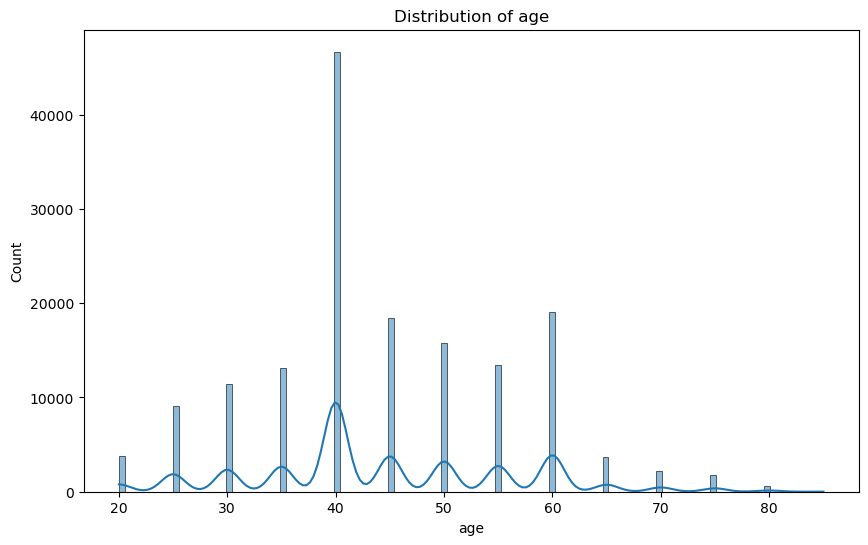

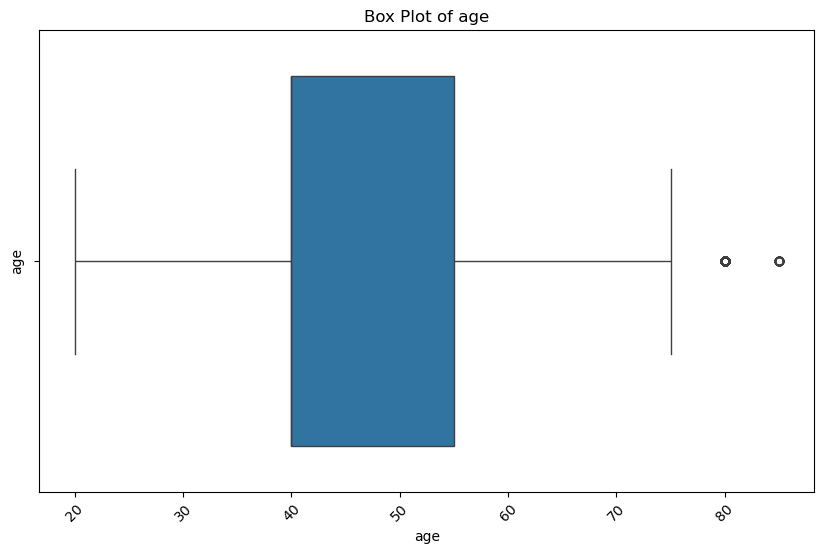


Summary Statistics for age:
count    159256.000000
mean         44.306626
std          11.842286
min          20.000000
25%          40.000000
50%          40.000000
75%          55.000000
max          85.000000
Name: age, dtype: float64




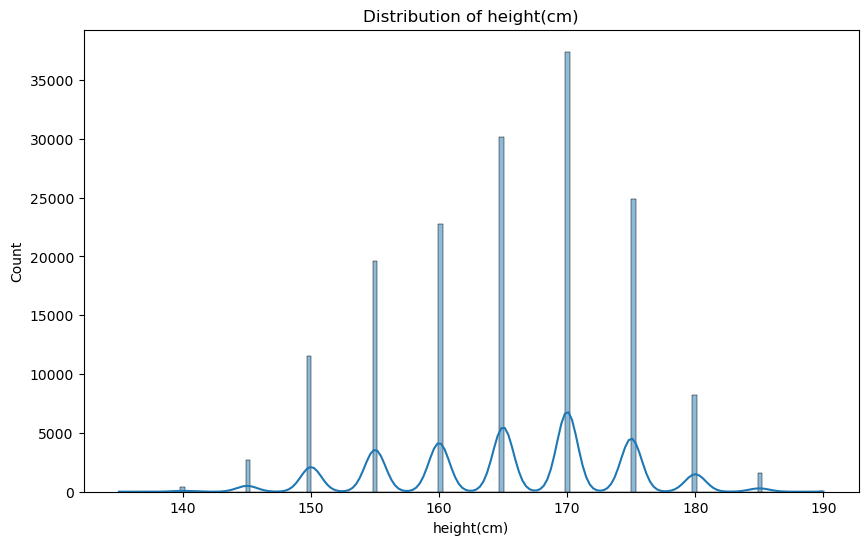

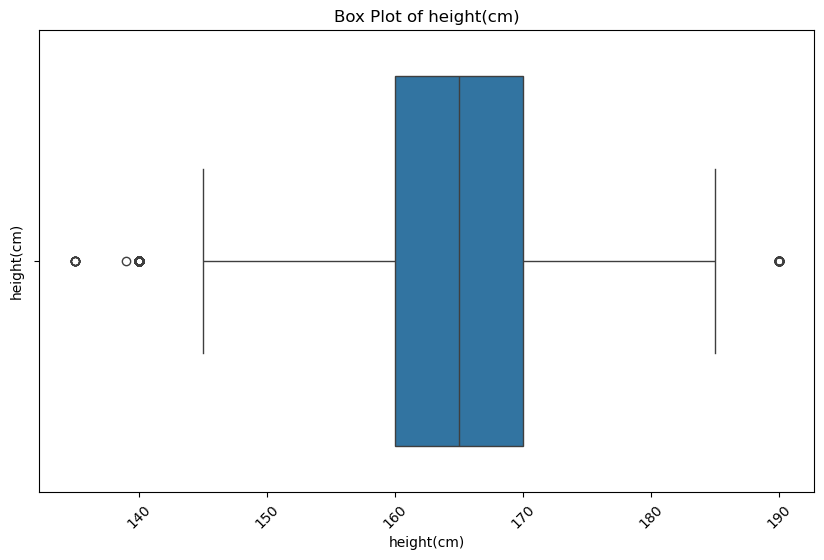


Summary Statistics for height(cm):
count    159256.000000
mean        165.266929
std           8.818970
min         135.000000
25%         160.000000
50%         165.000000
75%         170.000000
max         190.000000
Name: height(cm), dtype: float64




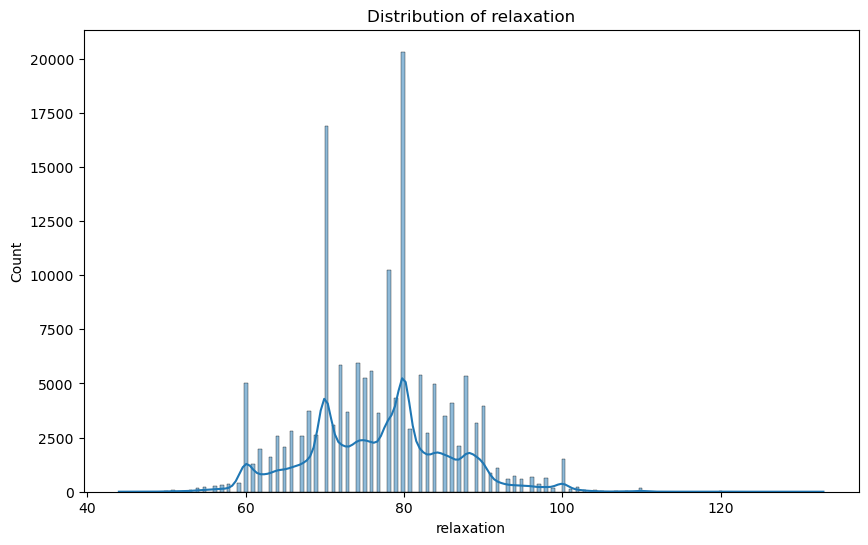

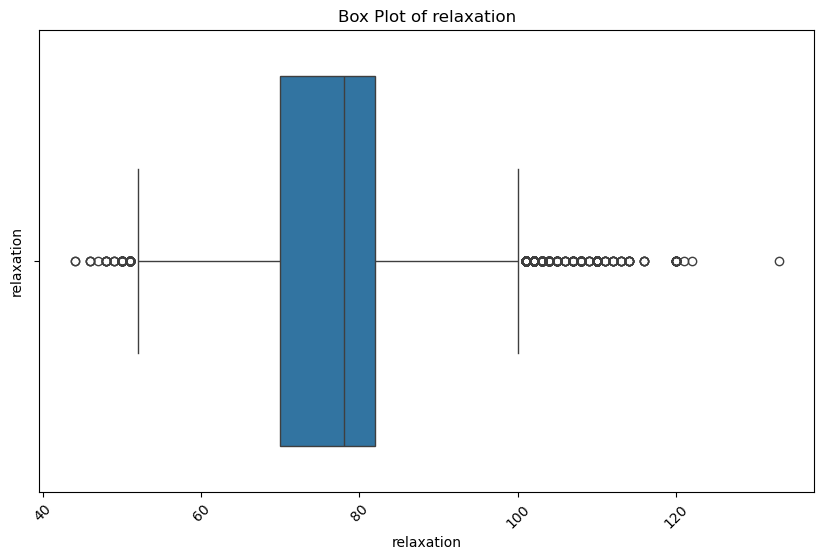


Summary Statistics for relaxation:
count    159256.000000
mean         76.874071
std           8.994642
min          44.000000
25%          70.000000
50%          78.000000
75%          82.000000
max         133.000000
Name: relaxation, dtype: float64




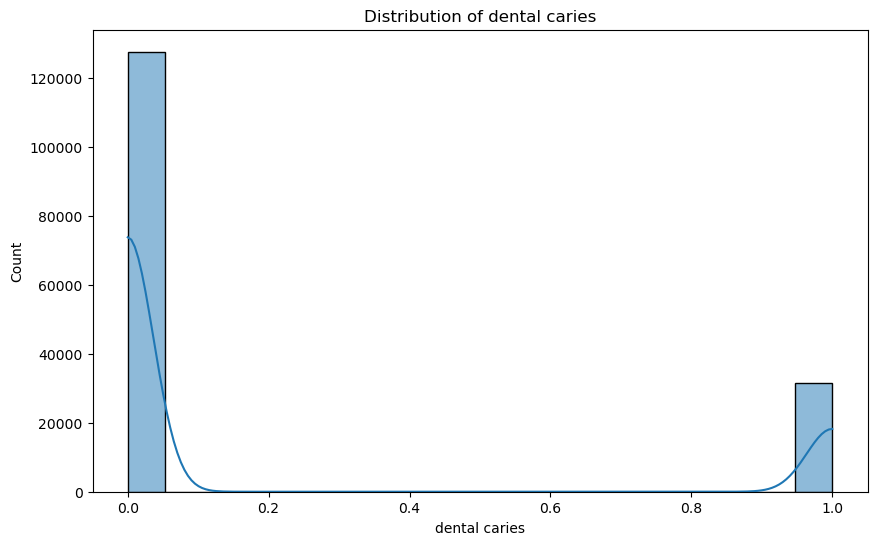

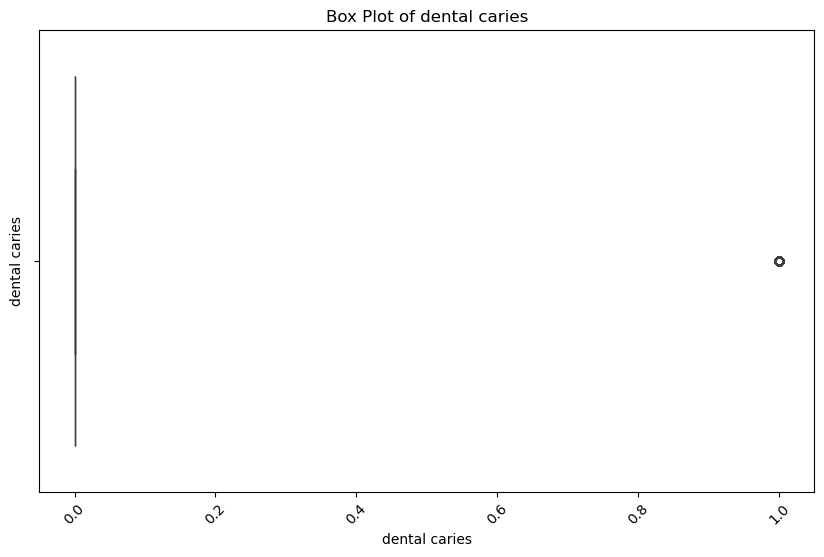


Summary Statistics for dental caries:
count    159256.000000
mean          0.197996
std           0.398490
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: dental caries, dtype: float64




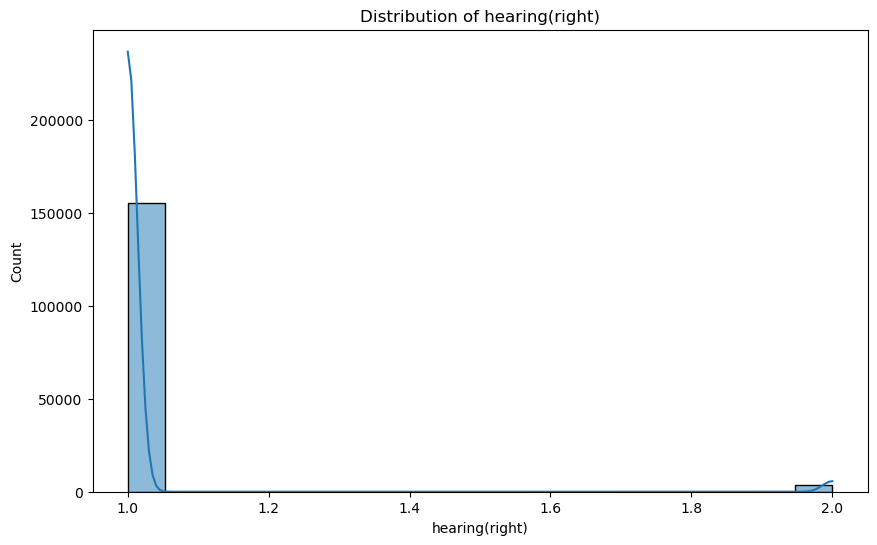

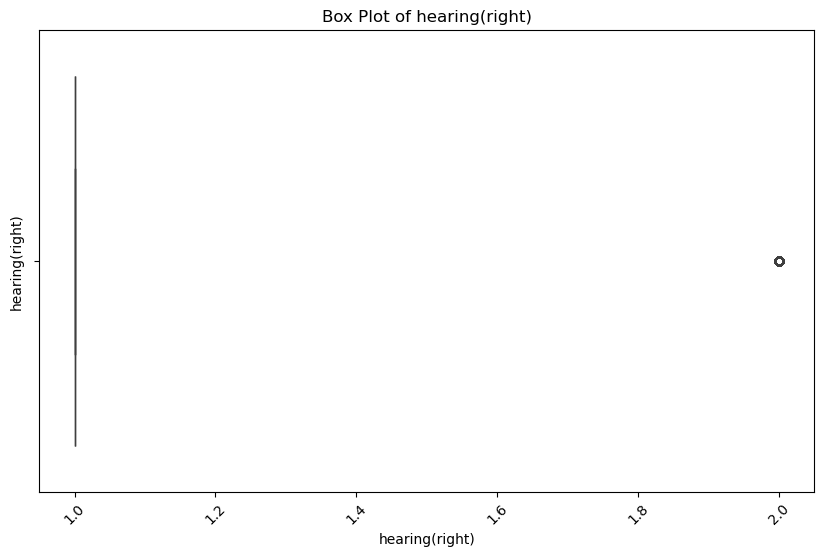


Summary Statistics for hearing(right):
count    159256.000000
mean          1.023421
std           0.151238
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: hearing(right), dtype: float64




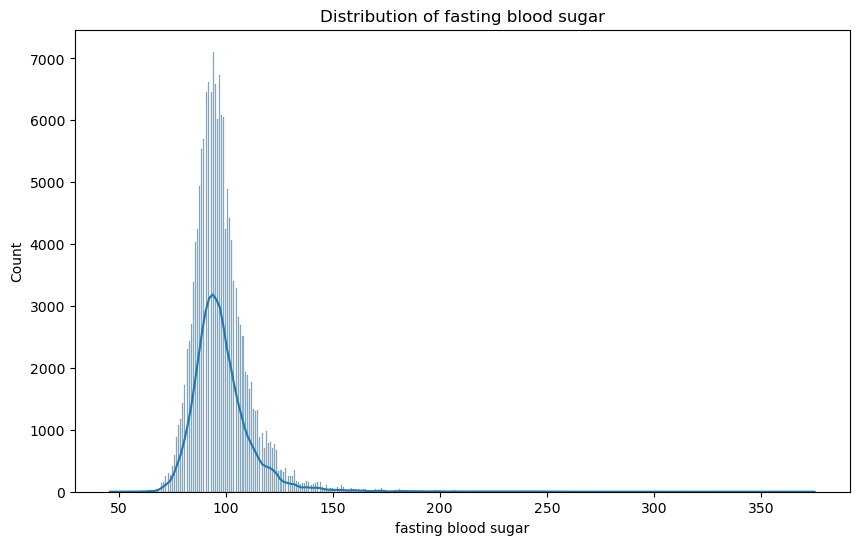

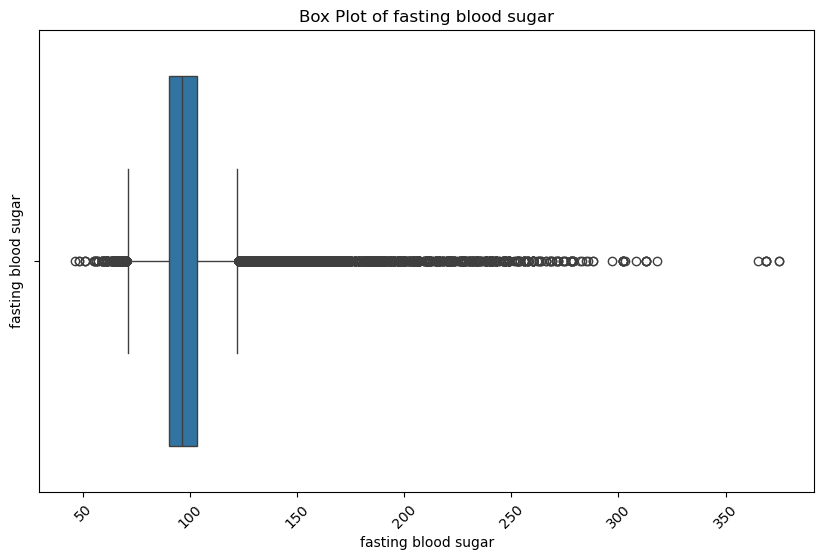


Summary Statistics for fasting blood sugar:
count    159256.000000
mean         98.352552
std          15.329740
min          46.000000
25%          90.000000
50%          96.000000
75%         103.000000
max         375.000000
Name: fasting blood sugar, dtype: float64




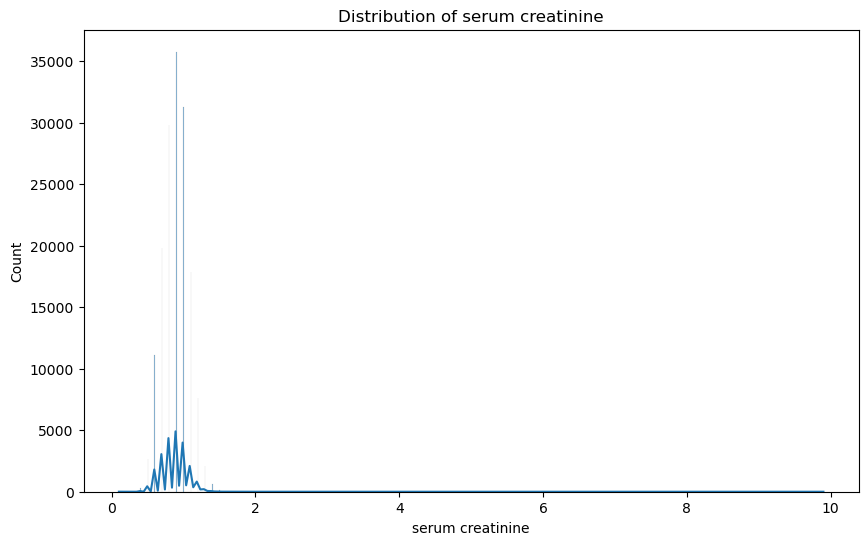

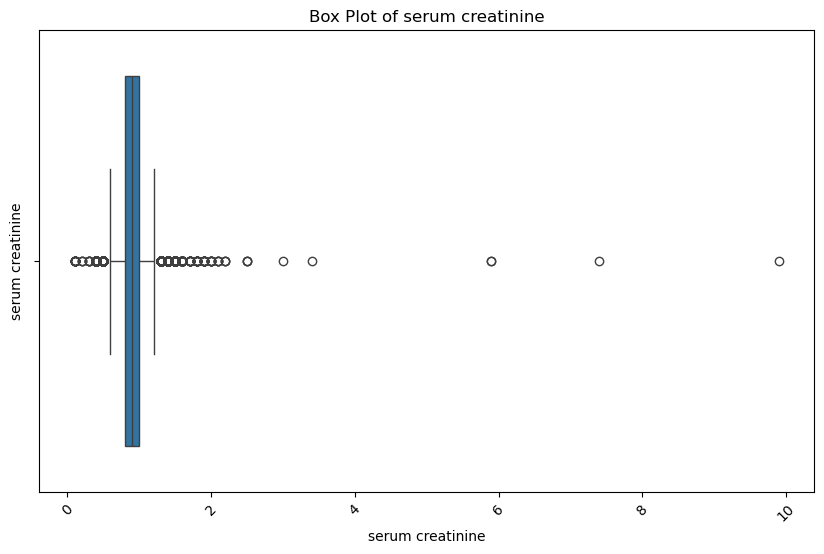


Summary Statistics for serum creatinine:
count    159256.000000
mean          0.892764
std           0.179346
min           0.100000
25%           0.800000
50%           0.900000
75%           1.000000
max           9.900000
Name: serum creatinine, dtype: float64




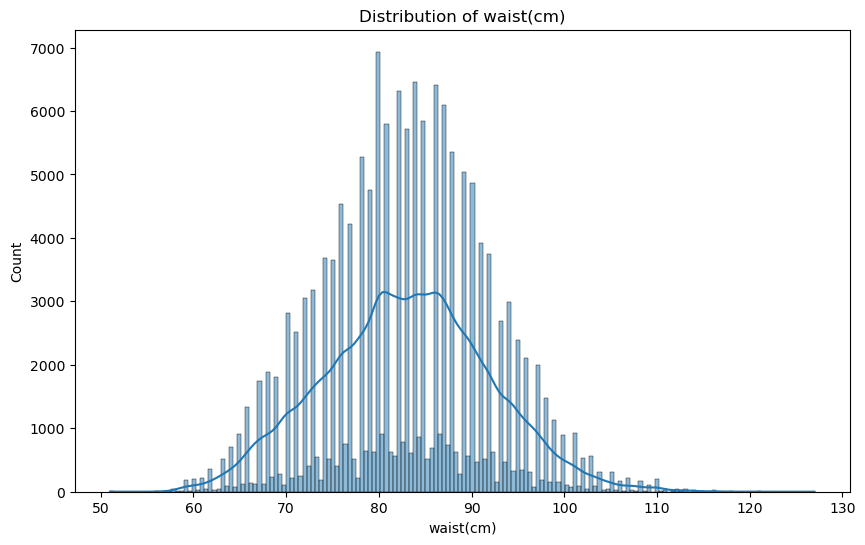

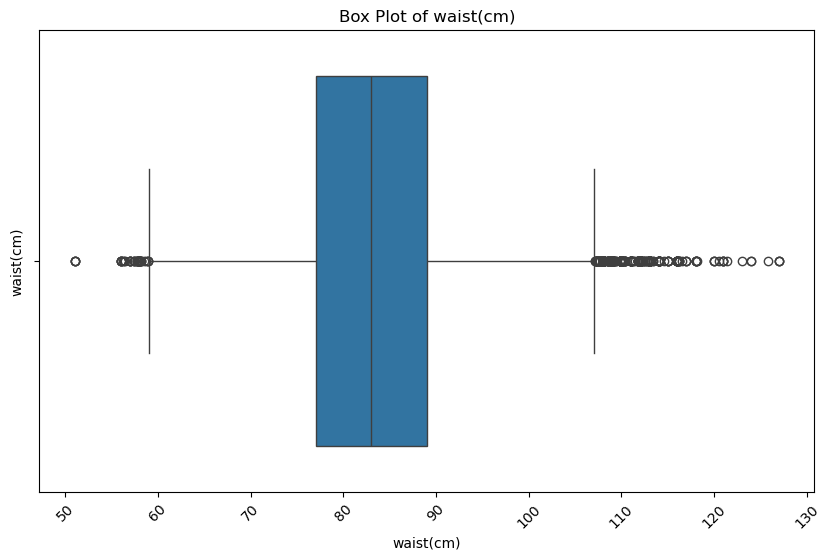


Summary Statistics for waist(cm):
count    159256.000000
mean         83.001990
std           8.957937
min          51.000000
25%          77.000000
50%          83.000000
75%          89.000000
max         127.000000
Name: waist(cm), dtype: float64




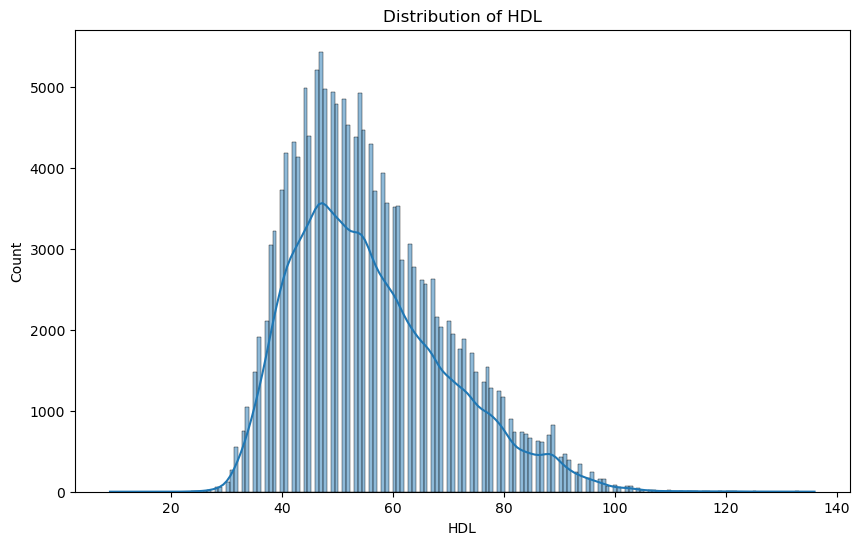

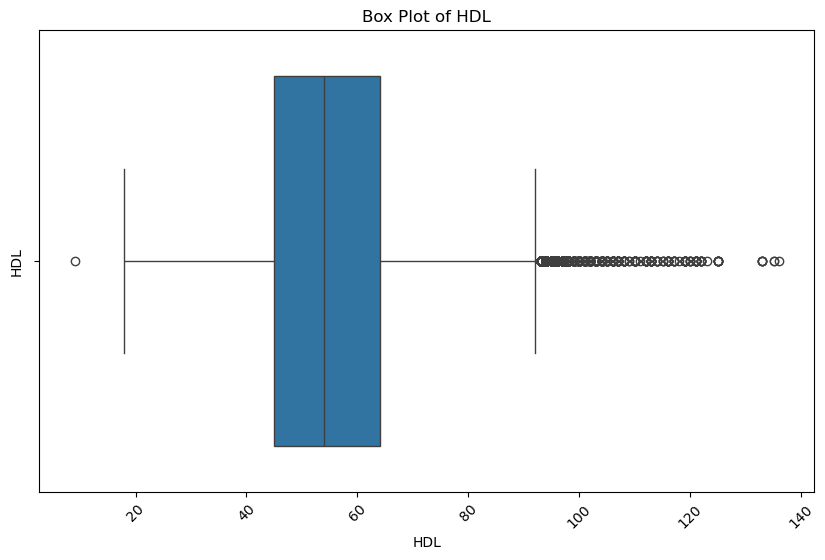


Summary Statistics for HDL:
count    159256.000000
mean         55.852684
std          13.964141
min           9.000000
25%          45.000000
50%          54.000000
75%          64.000000
max         136.000000
Name: HDL, dtype: float64




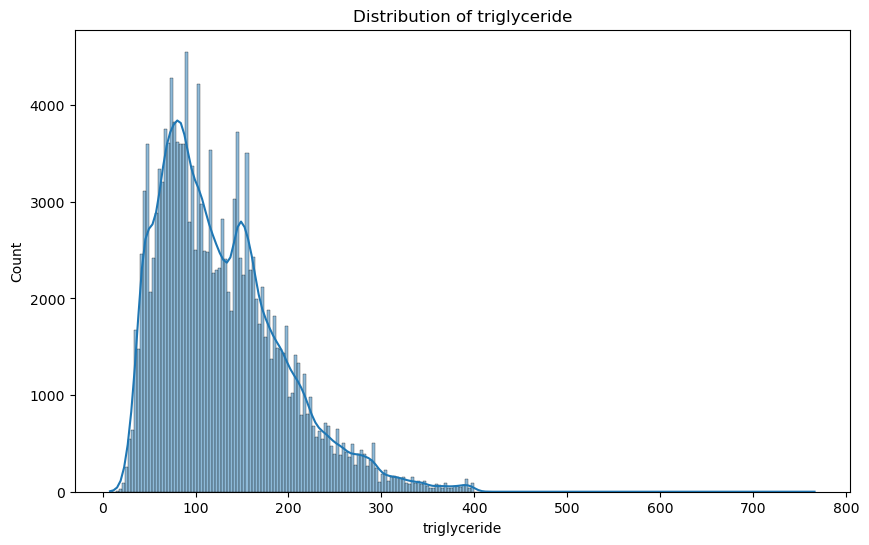

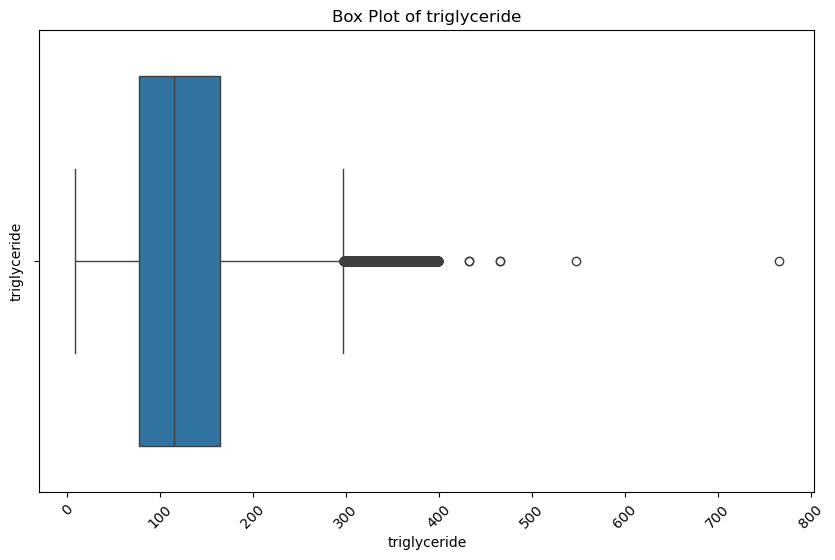


Summary Statistics for triglyceride:
count    159256.000000
mean        127.616046
std          66.188989
min           8.000000
25%          77.000000
50%         115.000000
75%         165.000000
max         766.000000
Name: triglyceride, dtype: float64




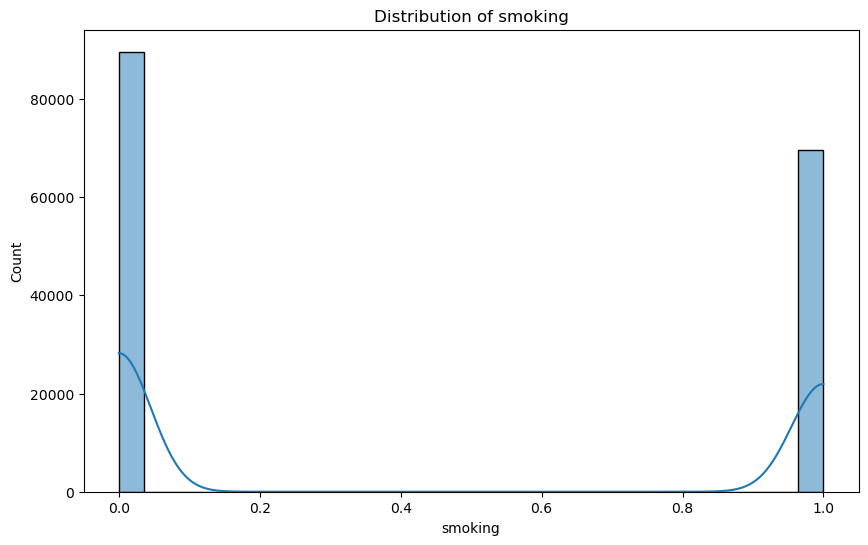

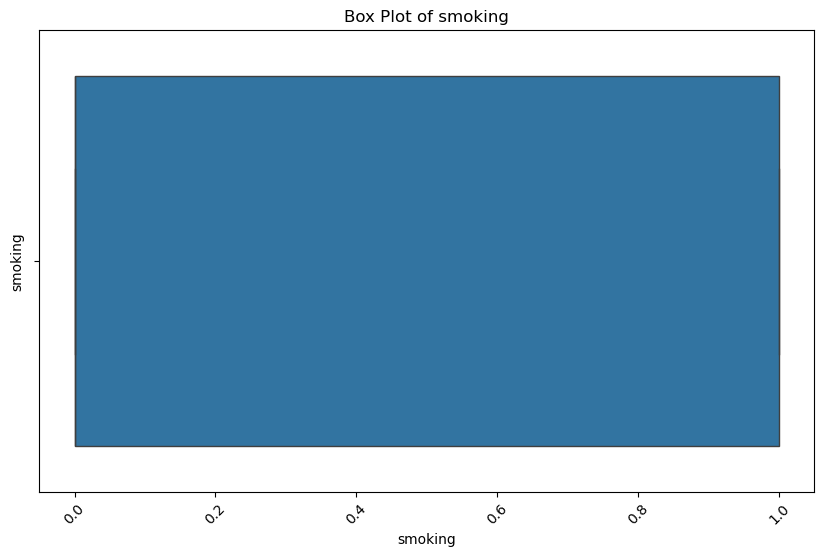


Summary Statistics for smoking:
count    159256.000000
mean          0.437365
std           0.496063
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: smoking, dtype: float64




In [22]:
# 3. Perform Data Analysis
print("\n3. Performing data analysis...")
print("\nUnivariate Analysis:")
perform_univariate_analysis(df)


Bivariate Analysis:


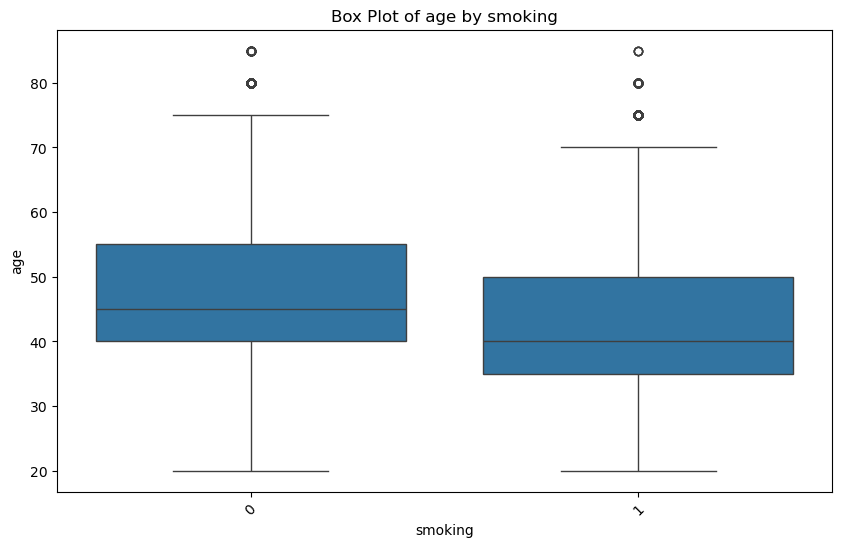

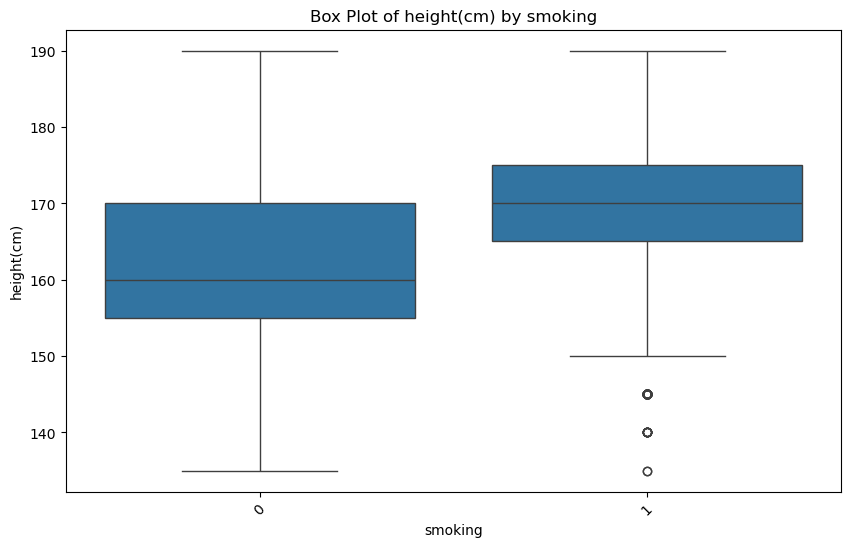

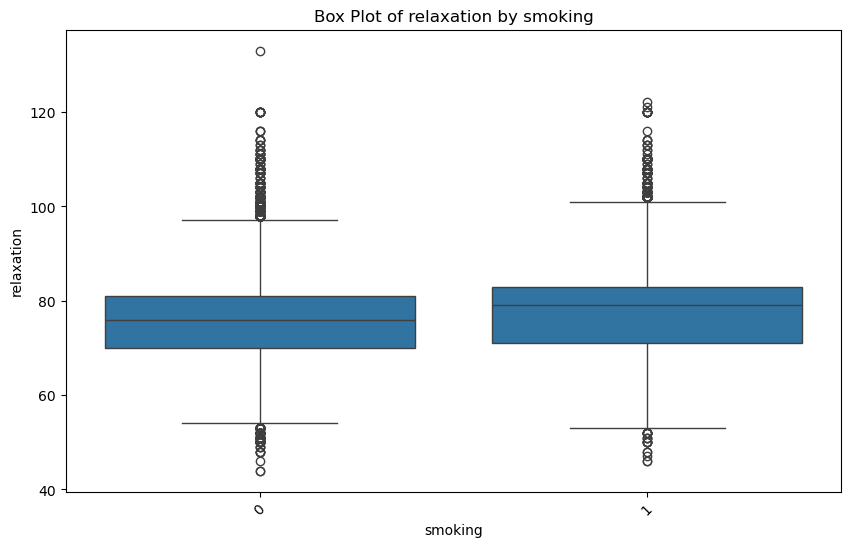

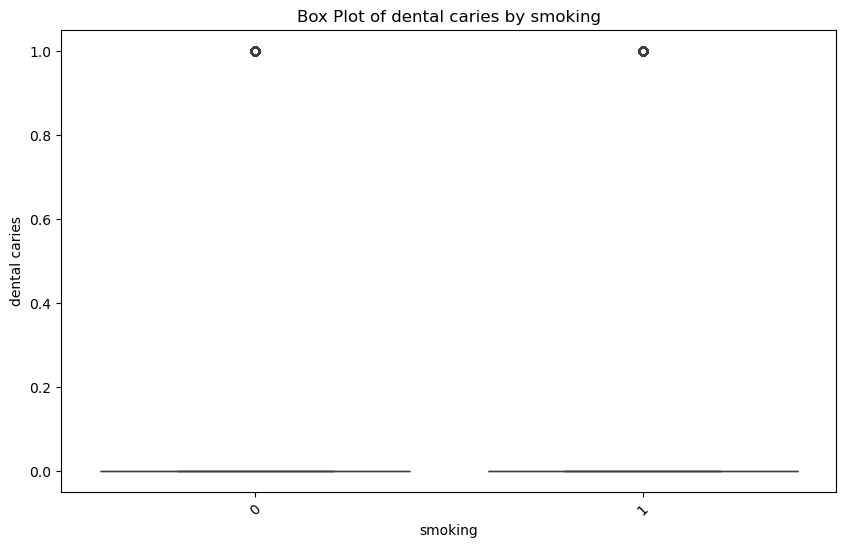

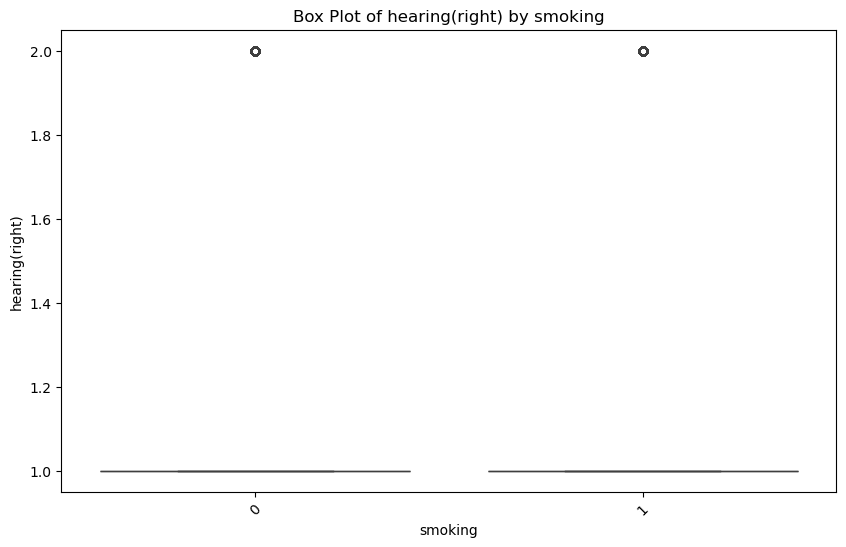

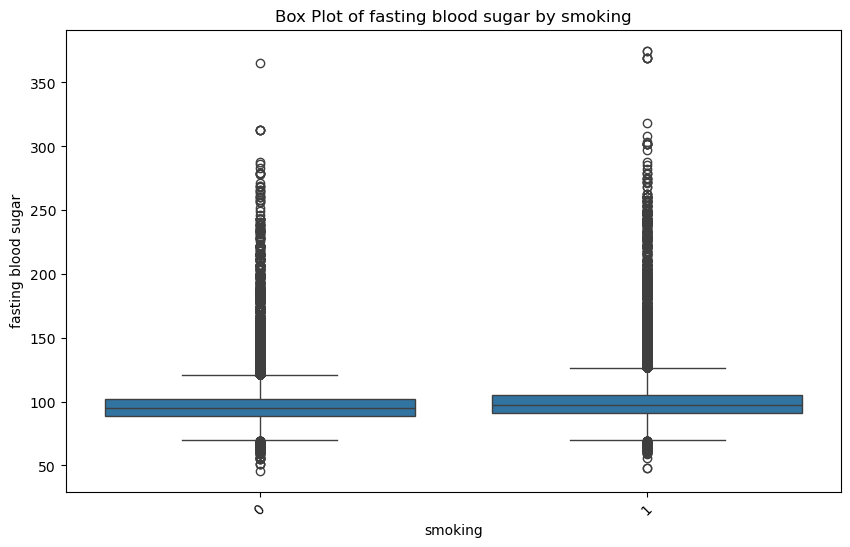

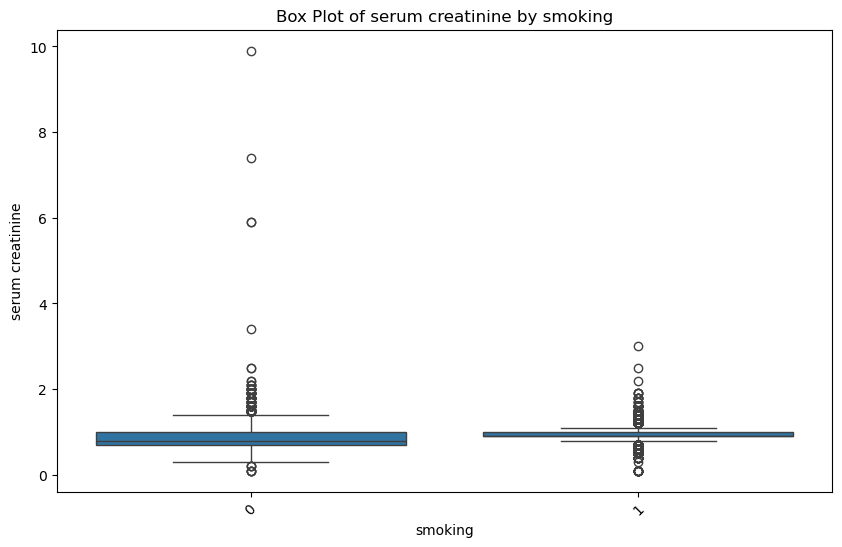

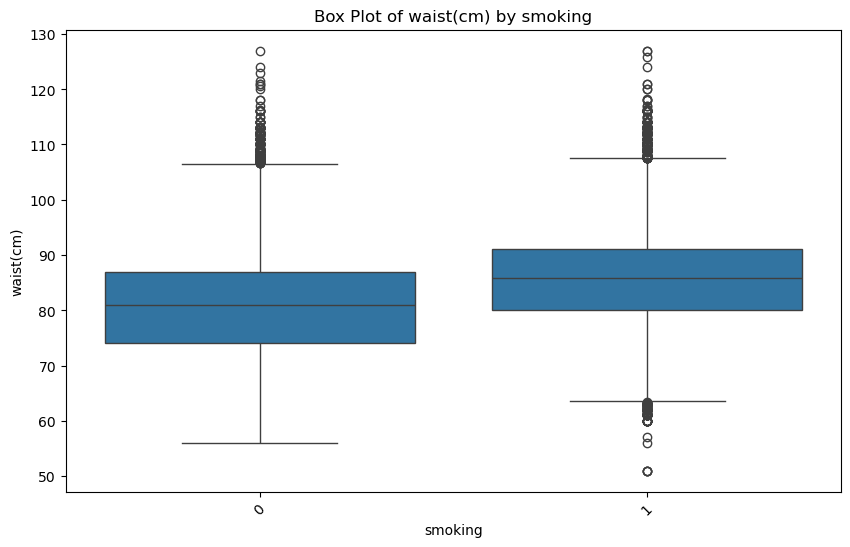

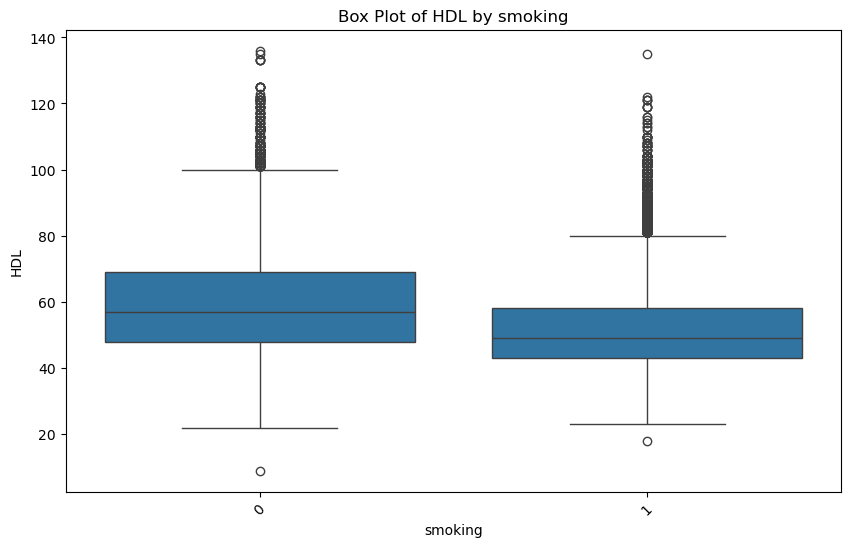

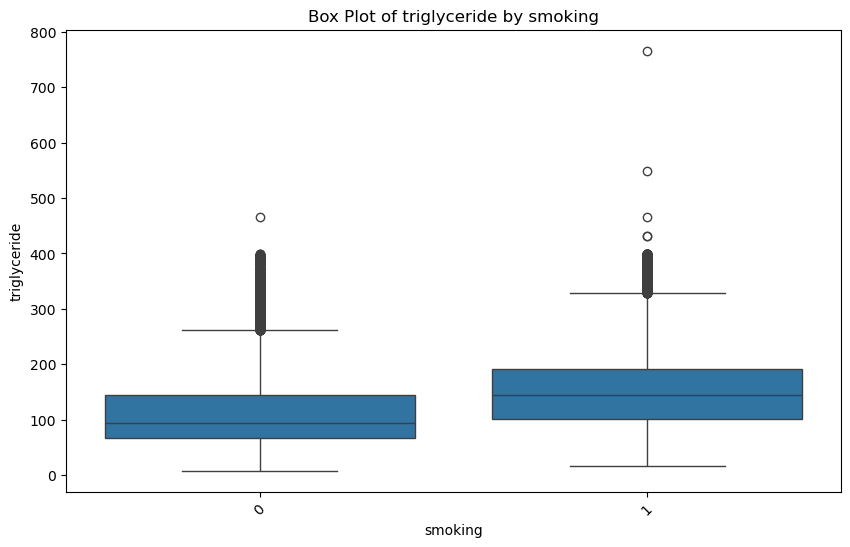

In [23]:
print("\nBivariate Analysis:")
perform_bivariate_analysis(df, 'smoking')


Multivariate Analysis:


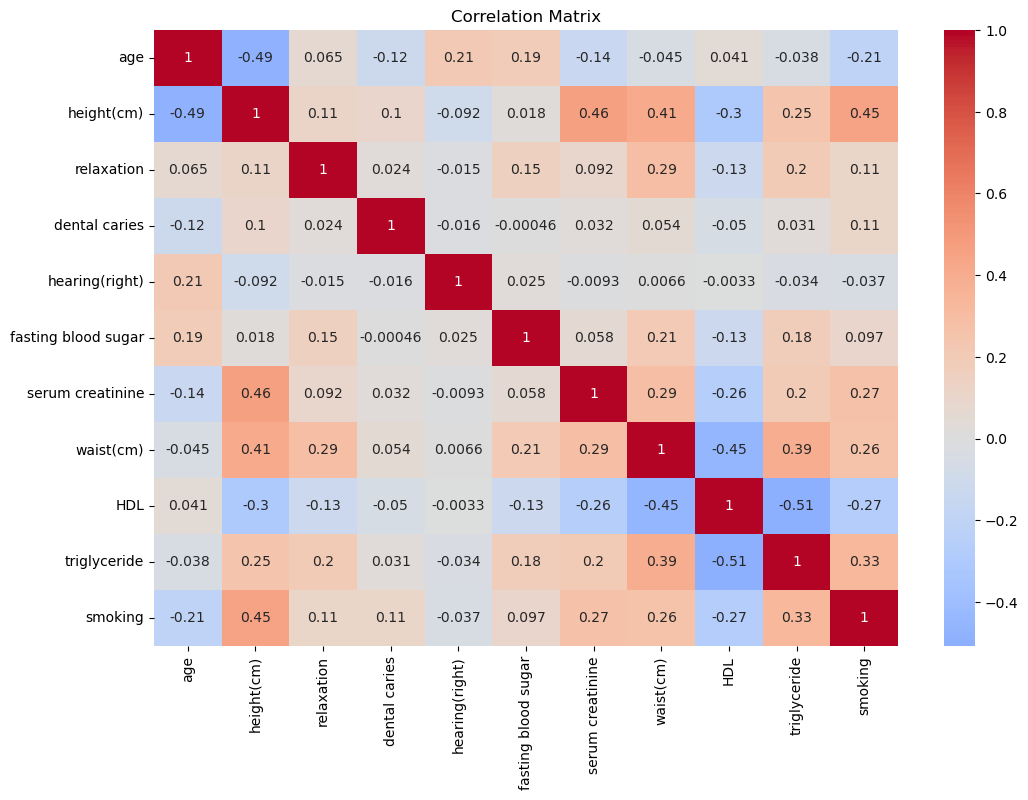

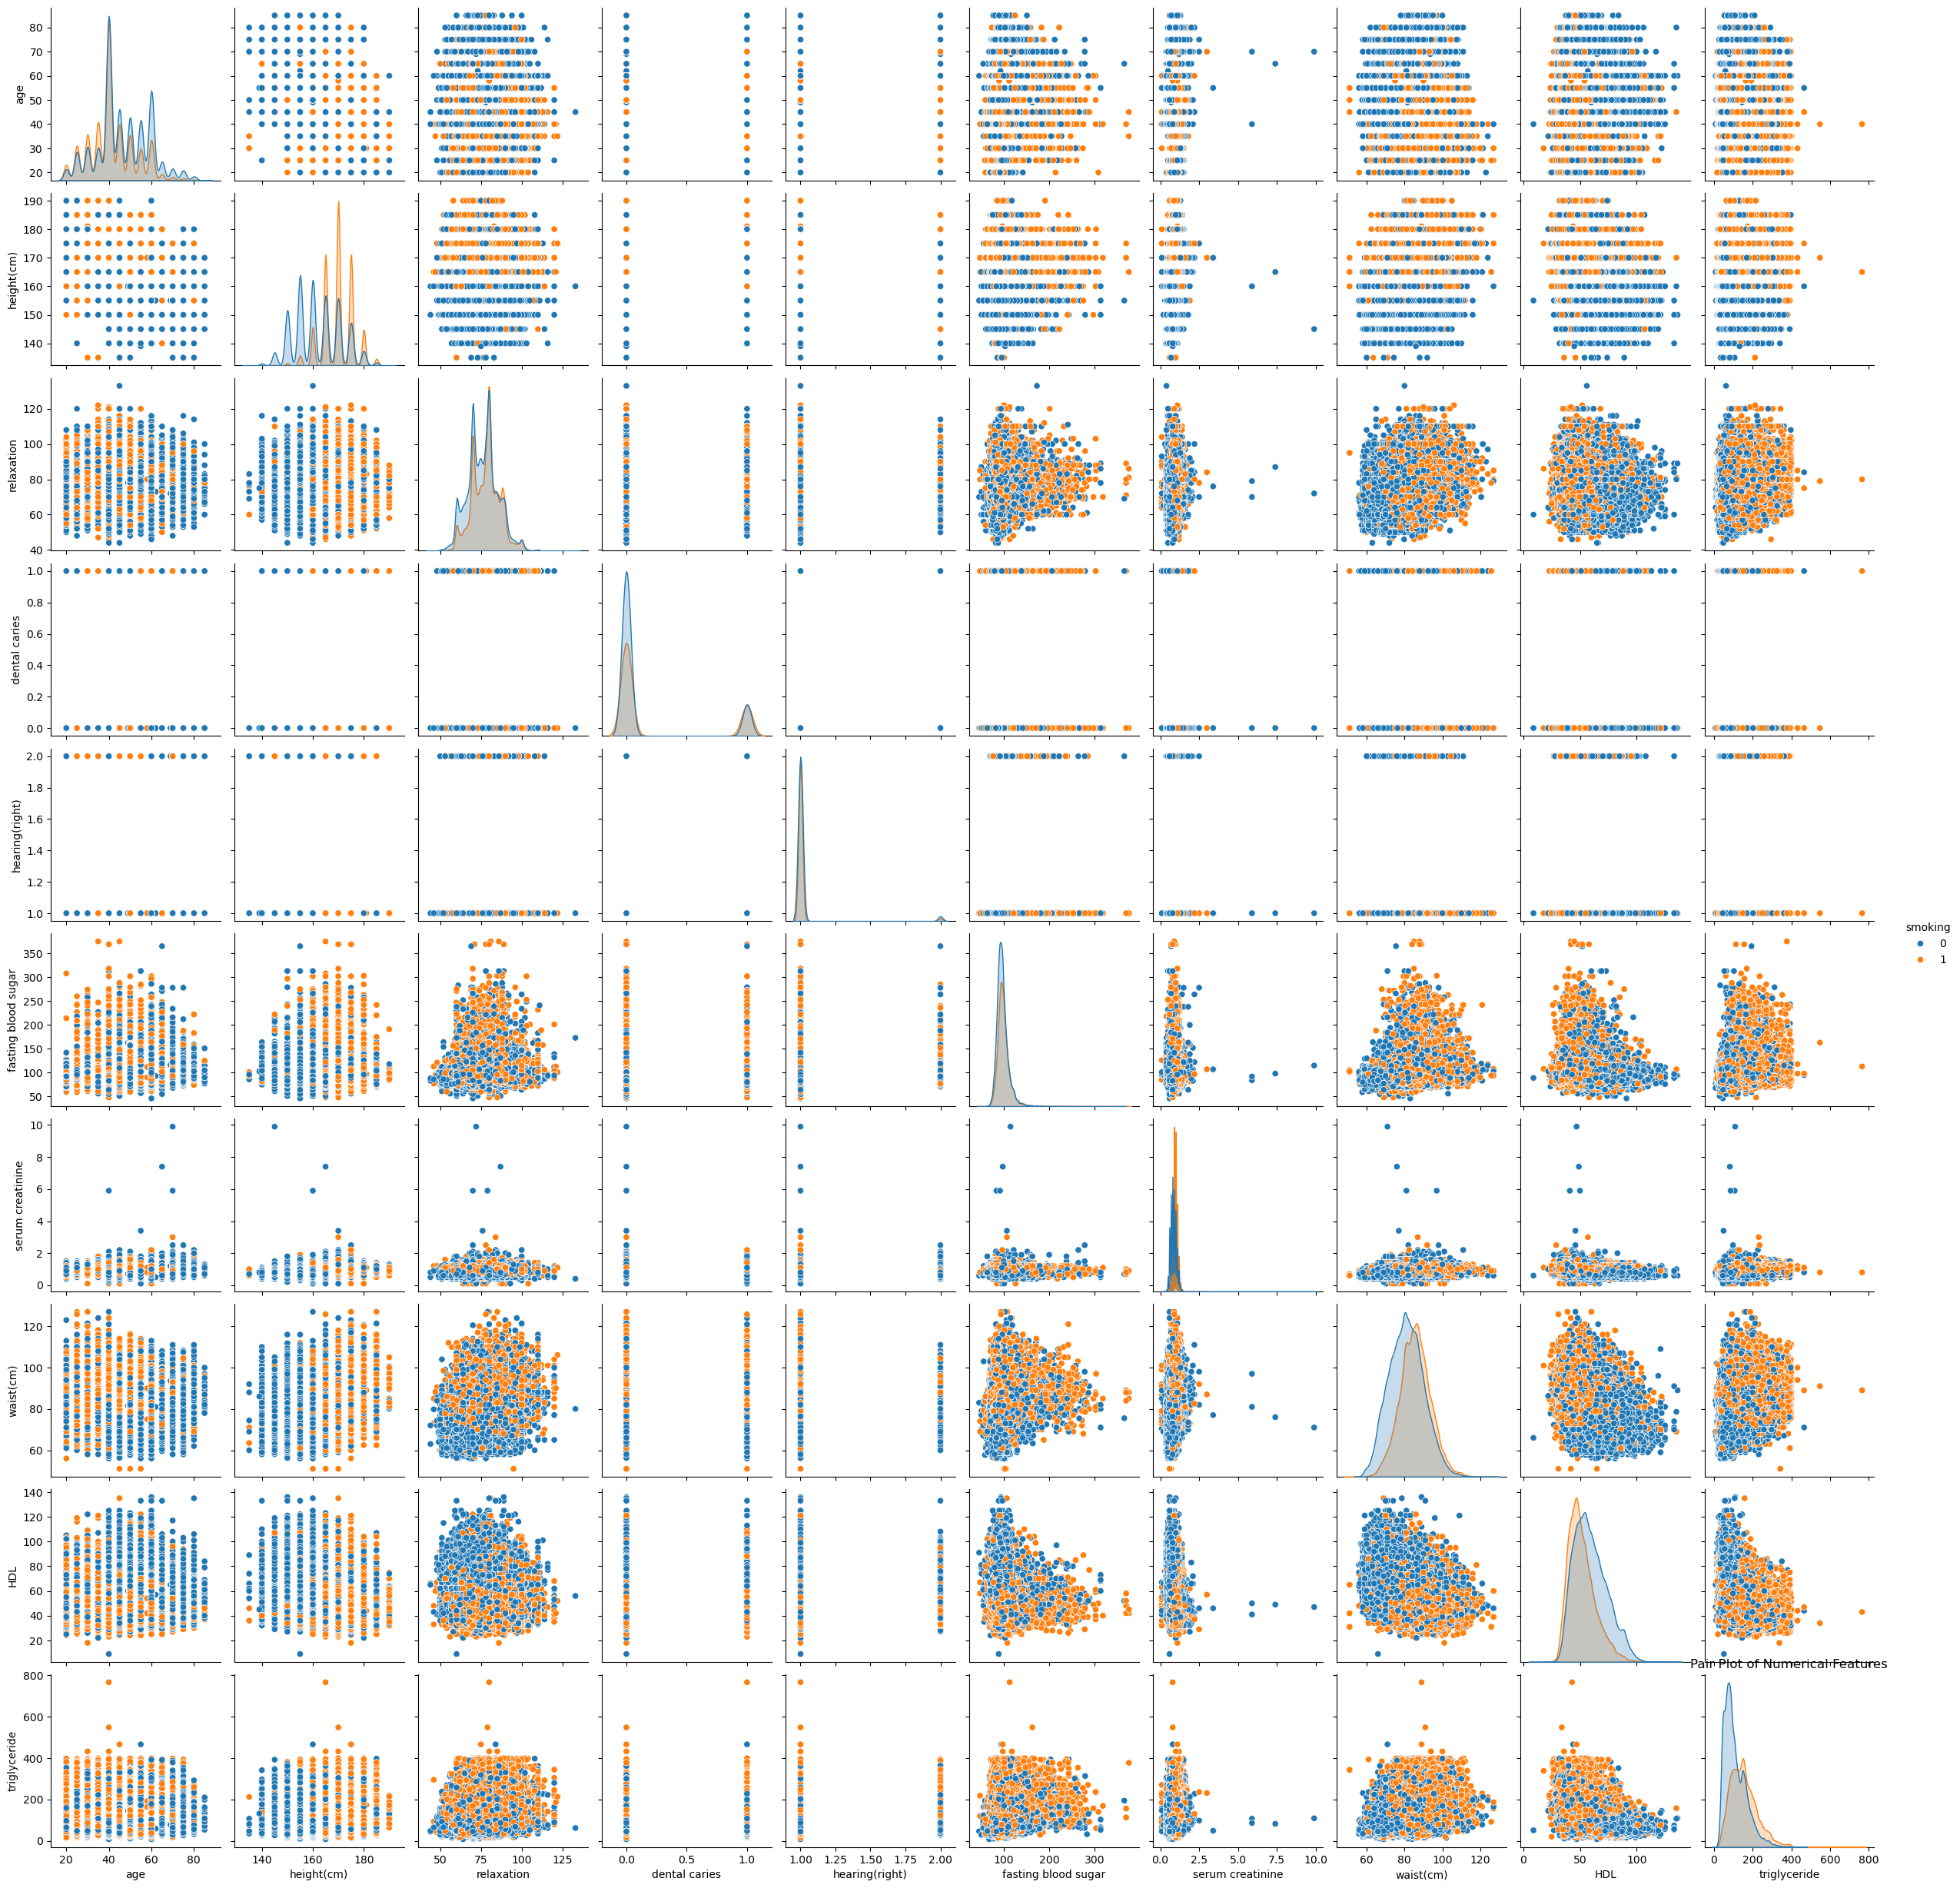

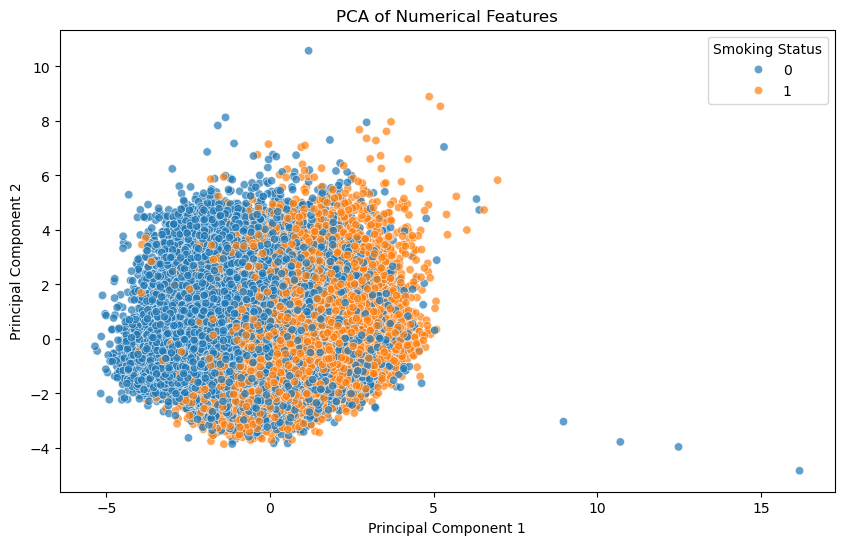

In [24]:
print("\nMultivariate Analysis:")
perform_multivariate_analysis(df)

In [4]:
# 4. Feature Engineering
print("\n4. Performing feature engineering...")
X_train_processed, y_train_processed, X_val_processed, X_test_processed = perform_feature_engineering(
    X_train, X_val, X_test, 
    
)


4. Performing feature engineering...


NameError: name 'X_train' is not defined

In [48]:
# 5. Train Ensemble Models
print("\n5. Training ensemble models...")
model_results = custom_train_ensemble_models(
    X_train_processed, 
    y_train_processed, 
    X_val_processed, 
    y_val
)



5. Training ensemble models...

Training Bagging model...
Bagging Model Validation Accuracy: 0.6990

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74     26907
           1       0.68      0.60      0.63     20870

    accuracy                           0.70     47777
   macro avg       0.69      0.69      0.69     47777
weighted avg       0.70      0.70      0.70     47777


Training Boosting model...
Boosting Model Validation Accuracy: 0.7010

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.55      0.68     26907
           1       0.61      0.89      0.72     20870

    accuracy                           0.70     47777
   macro avg       0.74      0.72      0.70     47777
weighted avg       0.75      0.70      0.70     47777


Training Random Forest model...
Random Forest Model Validation Accuracy: 0.6678

Classification Report:
              precisi

In [27]:
# 6. Find best model
best_model_name = max(model_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_model = model_results[best_model_name]['model']
print(f"\nBest performing model: {best_model_name}")
print(f"Validation accuracy: {model_results[best_model_name]['accuracy']:.4f}")



Best performing model: Gradient Boosting
Validation accuracy: 0.7460


In [50]:
# 7. Hyperparameter Tuning
print("\n6. Performing hyperparameter tuning on best model...")
tuned_model = tune_best_model(best_model, X_train_processed, y_train_processed)   



6. Performing hyperparameter tuning on best model...
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best cross-validation score: 0.7467091035712385


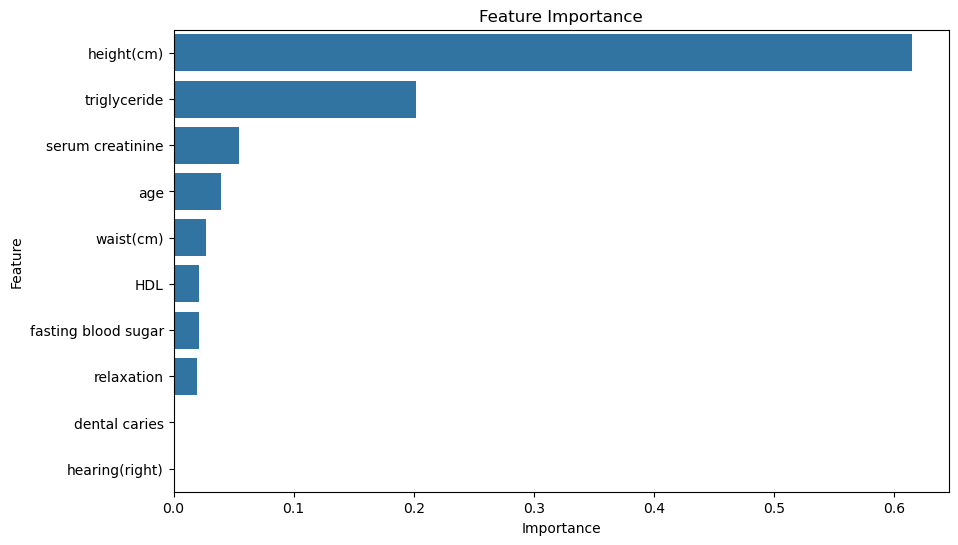


Top 5 Most Important Features:
            Feature  Importance
1        height(cm)    0.614624
9      triglyceride    0.201886
6  serum creatinine    0.054742
0               age    0.039746
7         waist(cm)    0.027162

Generating model explanations...


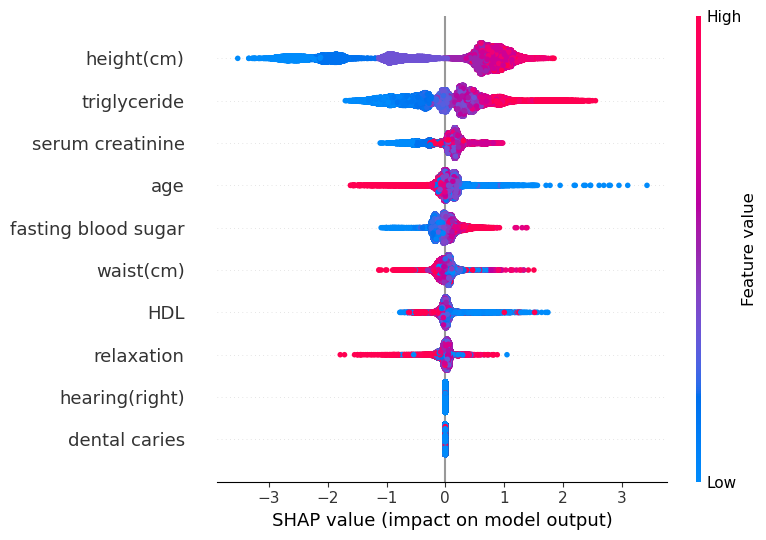

In [51]:
# 8. Feature importance and model interpretability (after tuning)
importance_df = analyze_feature_importance(tuned_model, X_train_processed, X_train.columns, y_train_processed)
print("\nTop 5 Most Important Features:")
print(importance_df.head())
print("\nGenerating model explanations...")
explain_predictions(tuned_model, X_train_processed, X_test_processed, X_train.columns)


In [52]:
# 9. Final Evaluation
print("\n7. Evaluating final model on test set...")
test_predictions = tuned_model.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, test_predictions)
print("\nFinal Test Results:")
print(f"Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_predictions))



7. Evaluating final model on test set...

Final Test Results:
Accuracy: 0.7444

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76     35626
           1       0.69      0.76      0.72     28077

    accuracy                           0.74     63703
   macro avg       0.74      0.75      0.74     63703
weighted avg       0.75      0.74      0.75     63703



In [54]:
# 10. Save results
print("\n8. Saving results...")
results = {
    'selected_features': list(X_train.columns),
    'best_model': best_model_name,
    'best_params': tuned_model.get_params(),
    'test_accuracy': test_accuracy
}

with open('analysis_results.txt', 'w') as f:
    for key, value in results.items():
        f.write(f"{key}: {value}\n")

print("\nAnalysis complete! Results saved to 'analysis_results.txt'")


8. Saving results...

Analysis complete! Results saved to 'analysis_results.txt'


main

In [19]:
def main():
    """Main function to run the complete analysis pipeline"""
    print("=== Smoking Prediction Analysis ===\n")
    
    # 1. Generate and load dataset
    print("1. Generating dataset...")
    df = generate_dataset()
    print("\nDataset shape:", df.shape)
    print("\nFeature summary:")
    print(df.info())
    
    # 2. Split the data
    print("\n2. Splitting data into train, validation, and test sets...")
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)
    
    # 3. Perform Data Analysis
    print("\n3. Performing data analysis...")
    print("\nUnivariate Analysis:")
    perform_univariate_analysis(df)
    
    print("\nBivariate Analysis:")
    perform_bivariate_analysis(df, 'smoking')
    
    print("\nMultivariate Analysis:")
    perform_multivariate_analysis(df)
    
    # 4. Feature Engineering
    print("\n4. Performing feature engineering...")
    X_train_processed, y_train_processed, X_val_processed, X_test_processed = perform_feature_engineering(
        X_train, X_val, X_test, y_train
    )
    
    # 5. Train Ensemble Models
    print("\n5. Training ensemble models...")
    model_results = custom_train_ensemble_models(
        X_train_processed, 
        y_train_processed, 
        X_val_processed, 
        y_val
    )
    
    # 6. Find best model
    best_model_name = max(model_results.items(), key=lambda x: x[1]['accuracy'])[0]
    best_model = model_results[best_model_name]['model']
    print(f"\nBest performing model: {best_model_name}")
    print(f"Validation accuracy: {model_results[best_model_name]['accuracy']:.4f}")
    
    # 7. Hyperparameter Tuning
    print("\n6. Performing hyperparameter tuning on best model...")
    tuned_model = tune_best_model(best_model, X_train_processed, y_train_processed)   
    
    # 8. Feature importance and model interpretability (after tuning)
    importance_df = analyze_feature_importance(tuned_model, X_train_processed, X_train.columns,y_train_processed)
    print("\nTop 5 Most Important Features:")
    print(importance_df.head())
    
    print("\nGenerating model explanations...")
    explain_predictions(tuned_model, X_train_processed, X_test_processed, X_train.columns)
    
    # 9. Final Evaluation
    print("\n7. Evaluating final model on test set...")
    test_predictions = tuned_model.predict(X_test_processed)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print("\nFinal Test Results:")
    print(f"Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions))
    
    # 10. Save results
    print("\n8. Saving results...")
    results = {
        'selected_features': list(X_train.columns),
        'best_model': best_model_name,
        'best_params': tuned_model.get_params(),
        'test_accuracy': test_accuracy
    }
    
    with open('analysis_results.txt', 'w') as f:
        for key, value in results.items():
            f.write(f"{key}: {value}\n")
    
    print("\nAnalysis complete! Results saved to 'analysis_results.txt'")

In [ ]:
if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"An error occurred: {str(e)}")